## Memcached throughput vs latency (Part 1)

### What system and workload were measured?

**Service:** Memcached `read` (GET-like) latency and throughput from **mcperf**-style summaries (histogram percentiles plus achieved **QPS** in the measurement window).

**Deployments / configurations (`part_1_logs/` filenames):**

| Run files | Scenario (resource interference) |
|-----------|----------------------------------|
| `without_*` | **Baseline** — no intentional contention workload |
| `cpu_*` | **CPU contention** |
| `l1d_*` | **L1 data cache contention** |
| `l1i_*` | **L1 instruction cache contention** |
| `l2_*` | **L2 cache contention** |
| `llc_*` | **Last-level cache (LLC) contention** |
| `membw_*` | **Memory bandwidth contention** |

Each scenario has **three** independent measurement runs (`*_1`, `*_2`, `*_3`) on the Part 1 cluster setup (`part1.yaml` and deployment used for experiments).

**y-axis quantity:** Client-observed **95th percentile** read latency, from log column `p95` (**microseconds** in the raw log), plotted in **milliseconds (ms)**.

**x-axis quantity:** **Achieved throughput** from column **QPS** in the logs, reported as Memcached-style **requests per second** (requests/s).

### Averages, linear axes, error bars

The figure uses **linear** scales on both axes (no logarithmic transform), **each starting at zero**.

For each nominal **target** load (`target` column, steps of about **5 thousand** requests/s up to **80 thousand**), we compute the mean over the three runs.

**What the error bars mean:** Bars extend **along both axes** and show **standard error of the mean (SEM)** over the three runs: \(SEM = s / \sqrt{n}\), with \(n=3\) and \(s\) the **sample standard deviation** (Bessel corrected). Interpretation:

| Direction | Measures uncertainty in… |
|-----------|--------------------------|
| **Horizontal (requests/s)** | Re-run variation in **mean achieved throughput** at the **same tagged target**. |
| **Vertical (milliseconds)** | Re-run variation in **mean 95th percentile latency**. |

Thus they characterize **experiment repeatability**, not per-request dispersion and not ambiguity in the percentile definition.

**Reuse for related Part 1 figures:** keep *x* from **0** to **80k** requests/s (`AXIS_X_REQUESTS_S` in code). The *y*-axis starts at **0** ms; the **upper** limit comes from the data (mean p95 + vertical SEM) plus a little margin.


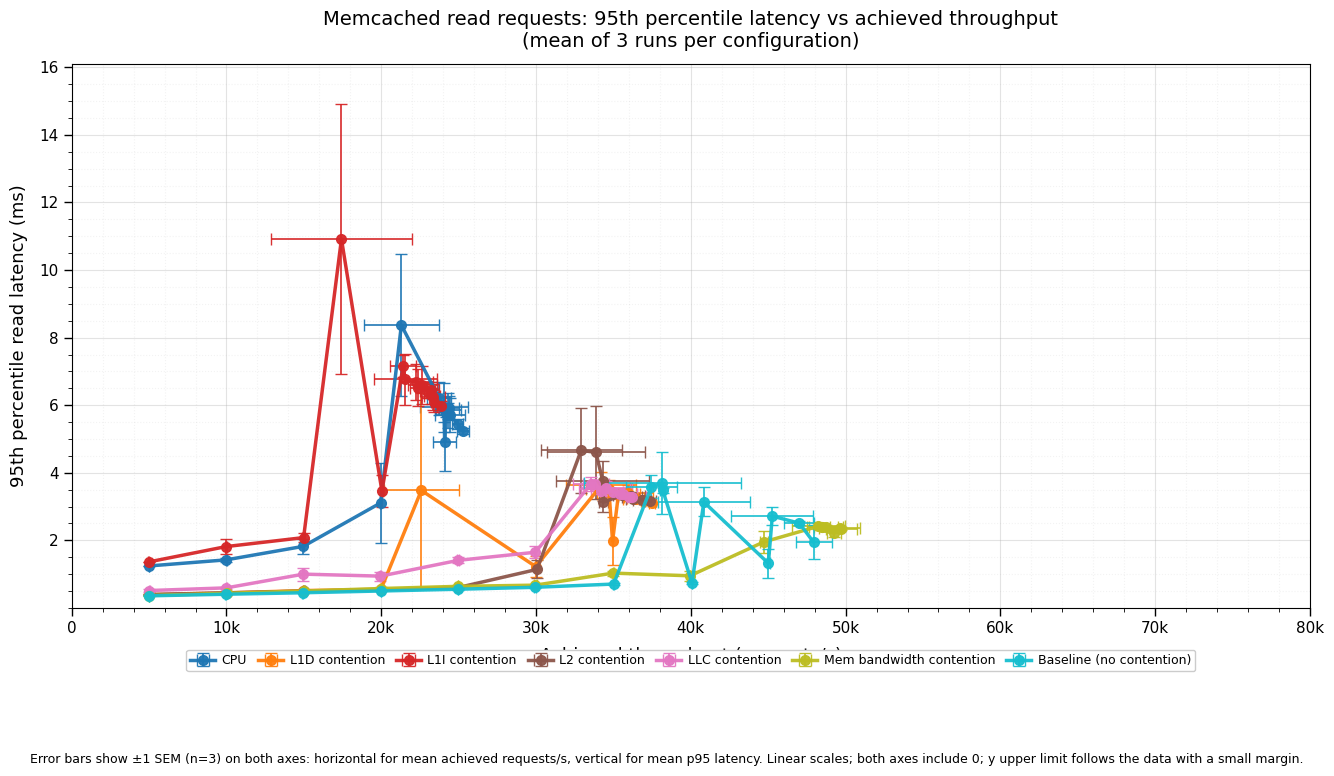

Runs averaged per configuration: 3
Target load steps (from logs): [np.float64(5000.0), np.float64(10000.0), np.float64(15000.0), np.float64(20000.0), np.float64(25000.0), np.float64(30000.0), np.float64(35000.0), np.float64(40000.0), np.float64(45000.0), np.float64(50000.0), np.float64(55000.0), np.float64(60000.0), np.float64(65000.0), np.float64(70000.0), np.float64(75000.0), np.float64(80000.0)]


In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, MultipleLocator, MaxNLocator


LOG_DIR = Path("part_1_logs")

# Shared x-axis limit for Part 1 throughput–latency figures
AXIS_X_REQUESTS_S = (0.0, 80_000.0)

CONFIGS = {
    "cpu": ["cpu_1.txt", "cpu_2.txt", "cpu_3.txt"],
    "l1d": ["l1d_1.txt", "l1d_2.txt", "l1d_3.txt"],
    "l1i": ["l1i_1.txt", "l1i_2.txt", "l1i_3.txt"],
    "l2": ["l2_1.txt", "l2_2.txt", "l2_3.txt"],
    "llc": ["llc_1.txt", "llc_2.txt", "llc_3.txt"],
    "membw": ["membw_1.txt", "membw_2.txt", "membw_3.txt"],
    "without": ["without_1.txt", "without_2.txt", "without_3.txt"],
}

DISPLAY_NAMES = {
    "cpu": "CPU",
    "l1d": "L1D contention",
    "l1i": "L1I contention",
    "l2": "L2 contention",
    "llc": "LLC contention",
    "membw": "Mem bandwidth contention",
    "without": "Baseline (no contention)",
}


def load_run(path: Path) -> pd.DataFrame:
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if line.startswith("Warning") or line.startswith("CPU Usage"):
                break
            if not line.startswith("read"):
                continue
            parts = line.split()
            target = float(parts[-1])
            qps = float(parts[-2])
            p95_us = float(parts[12])
            rows.append({"target": target, "qps": qps, "p95_ms": p95_us / 1000.0})
    return pd.DataFrame(rows)


runs_per_config = len(next(iter(CONFIGS.values())))
assert all(len(files) == runs_per_config for files in CONFIGS.values())

records = []
for cfg, filenames in CONFIGS.items():
    for fname in filenames:
        df_r = load_run(LOG_DIR / fname)
        df_r["config"] = cfg
        df_r["run"] = fname.split("_")[1].split(".")[0]
        records.append(df_r)

all_df = pd.concat(records, ignore_index=True)


def sem_series(s: pd.Series) -> float:
    vals = s.to_numpy(dtype=float)
    n = vals.size
    if n <= 1:
        return 0.0
    return float(vals.std(ddof=1) / np.sqrt(n))


summary = all_df.groupby(["config", "target"], as_index=False).agg(
    qps_mean=("qps", "mean"),
    qps_sem=("qps", sem_series),
    p95_ms_mean=("p95_ms", "mean"),
    p95_ms_sem=("p95_ms", sem_series),
)


def format_requests_axis_ticks(value, _pos=None):
    """Abbreviate large throughput values (e.g. 40k, 1.2M) instead of long digit strings."""
    v = float(value)
    if abs(v) < 1e-9:
        return "0"
    if abs(v) >= 1e6:
        m = v / 1e6
        s = f"{m:.1f}".rstrip("0").rstrip(".")
        return f"{s}M"
    if abs(v) >= 1000:
        k = v / 1000
        s = f"{k:.1f}".rstrip("0").rstrip(".") if k % 1 else f"{int(k)}"
        return f"{s}k"
    return f"{int(v)}"


fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(CONFIGS)))

for i, cfg in enumerate(CONFIGS.keys()):
    sub = summary.loc[summary["config"] == cfg].sort_values("qps_mean")
    ax.errorbar(
        sub["qps_mean"],
        sub["p95_ms_mean"],
        xerr=sub["qps_sem"],
        yerr=sub["p95_ms_sem"],
        label=DISPLAY_NAMES[cfg],
        fmt="-o",
        capsize=4,
        linewidth=2.5,
        markersize=7,
        color=colors[i],
        elinewidth=1.25,
        alpha=0.95,
        zorder=3,
    )

ax.set_xlabel("Achieved throughput (requests/s)", fontsize=13, labelpad=8)
ax.set_ylabel("95th percentile read latency (ms)", fontsize=13, labelpad=8)
ax.set_xlim(*AXIS_X_REQUESTS_S)
# y: always from 0; upper limit from data (mean + SEM) + headroom
y_roof = float(
    np.nanmax(
        summary["p95_ms_mean"].to_numpy(dtype=float)
        + summary["p95_ms_sem"].to_numpy(dtype=float)
    )
)
ax.set_ylim(0.0, y_roof * 1.08 if y_roof > 0 else 1.0)

ax.set_xscale("linear")
ax.set_yscale("linear")

ax.xaxis.set_major_locator(MultipleLocator(10_000))
ax.xaxis.set_major_formatter(FuncFormatter(format_requests_axis_ticks))
ax.yaxis.set_major_locator(MaxNLocator(nbins=10, prune="lower"))
ax.minorticks_on()
ax.tick_params(axis="both", which="major", labelsize=11, length=6, width=1)
ax.tick_params(axis="both", which="minor", labelsize=9, length=3)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15, linestyle=":")
ax.set_axisbelow(True)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.065),
    ncol=7,
    fontsize=9,
    framealpha=1.0,
    columnspacing=0.9,
    handletextpad=0.5,
    borderpad=0.35,
)

ax.set_title(
    "Memcached read requests: 95th percentile latency vs achieved throughput\n"
    f"(mean of {runs_per_config} runs per configuration)",
    fontsize=14,
    pad=12,
)

caption = (
    "Error bars show ±1 SEM (n=3) on both axes: horizontal for mean achieved requests/s, vertical for mean p95 latency. "
    "Linear scales; both axes include 0; y upper limit follows the data with a small margin."
)
fig.text(0.5, 0.02, caption, ha="center", fontsize=9, transform=fig.transFigure)

fig.tight_layout(rect=(0.02, 0.11, 0.98, 0.98))
plt.show()

print(f"Runs averaged per configuration: {runs_per_config}")
print(f"Target load steps (from logs): {sorted(all_df['target'].unique())}")